In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
print(sys.executable)

C:\Users\aksha\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
import pandas as pd
from prophet import Prophet

#### Time series of the log daily page views for the Wikipedia page for Peyton Manning. 

In [19]:
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv')
df.head()
peyton_data = df.copy()

### Quick Start

In [20]:
m = Prophet()
m.fit(df)

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\g9ccdiue.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\u__0l5dm.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=34572', 'data', 'file=C:\\Users\\aksha\\

In [5]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [6]:
forecast = m.predict(future)
forecast[['ds','yhat','yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.206964,7.449828,8.876938
3266,2017-01-16,8.531958,7.803754,9.247704
3267,2017-01-17,8.319376,7.569428,9.053367
3268,2017-01-18,8.151991,7.426755,8.851201
3269,2017-01-19,8.163908,7.432947,8.852163


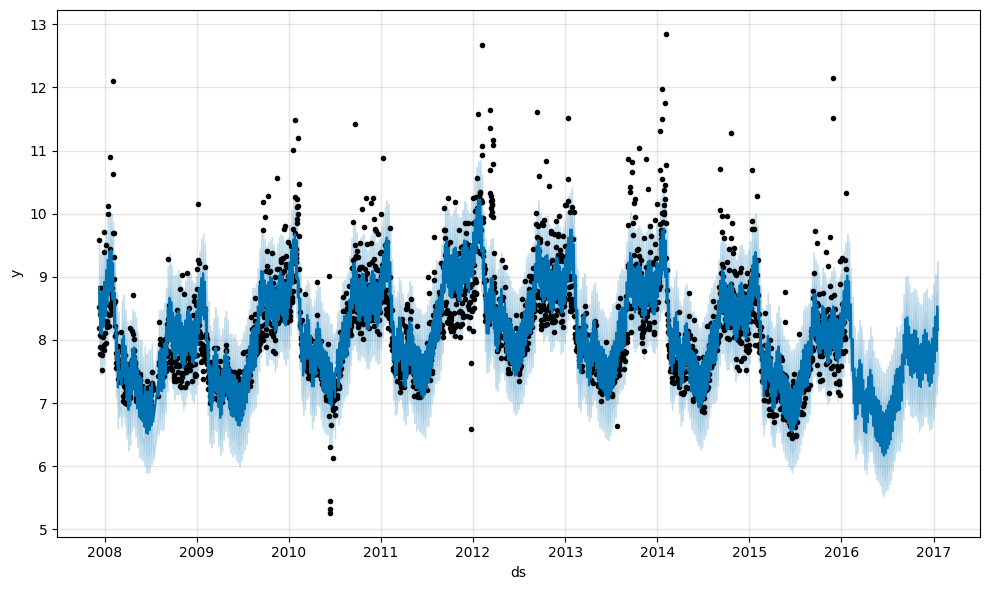

In [7]:
fig1 = m.plot(forecast)

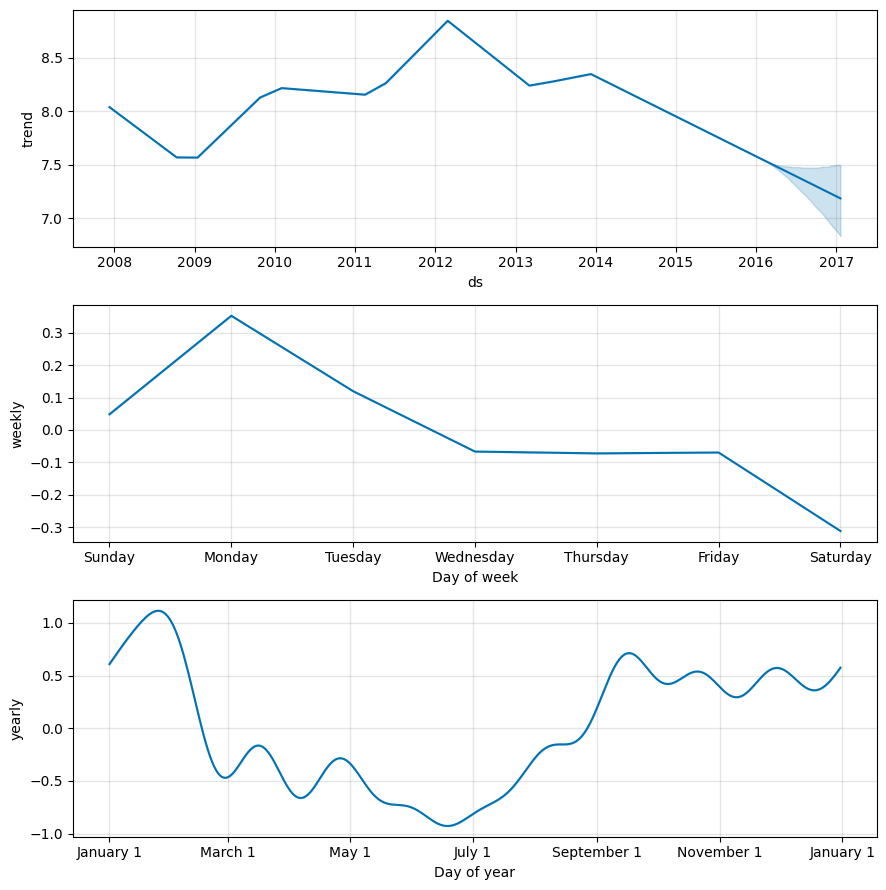

In [8]:
fig2 = m.plot_components(forecast)

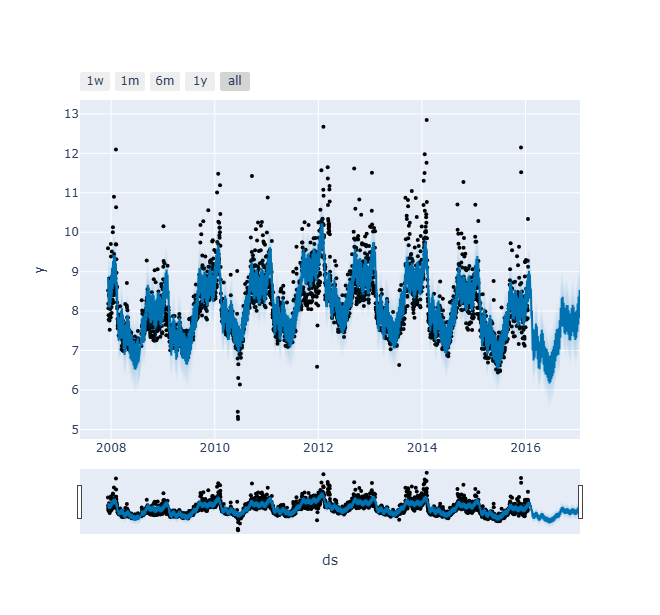

In [9]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

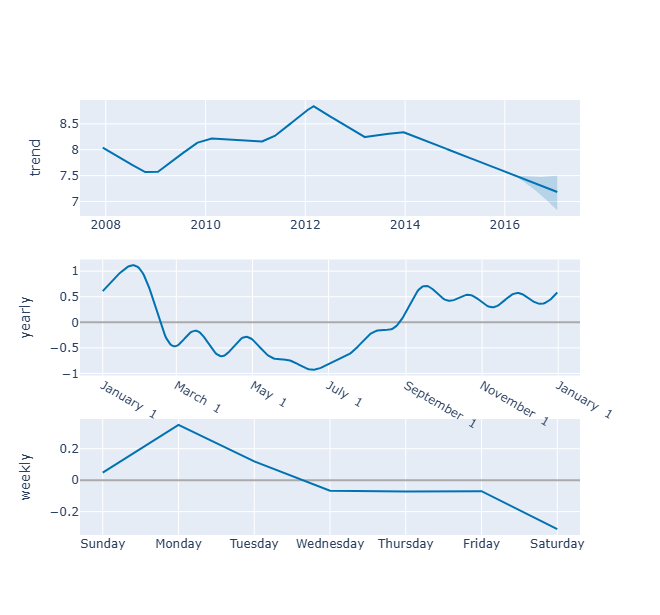

In [10]:
plot_components_plotly(m, forecast)

### Saturating Forecasts

#### The log number of page visits to the R (programming language) page on Wikipedia:

In [11]:
examples/example_wp_log_R.csv

NameError: name 'examples' is not defined

In [12]:
df = pd.read_csv('https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_R.csv')
df.head()

,ds,y
0,2008-01-30,5.976351
1,2008-01-16,6.049733
2,2008-01-17,6.011267
3,2008-01-14,5.953243
4,2008-01-15,5.910797


In [13]:
df['cap'] = 8.5

In [14]:
m = Prophet(growth = 'logistic')
m.fit(df)

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\u9k0z4hw.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\vc2z1j24.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=26059', 'data', 'file=C:\\Users\\aksha\\

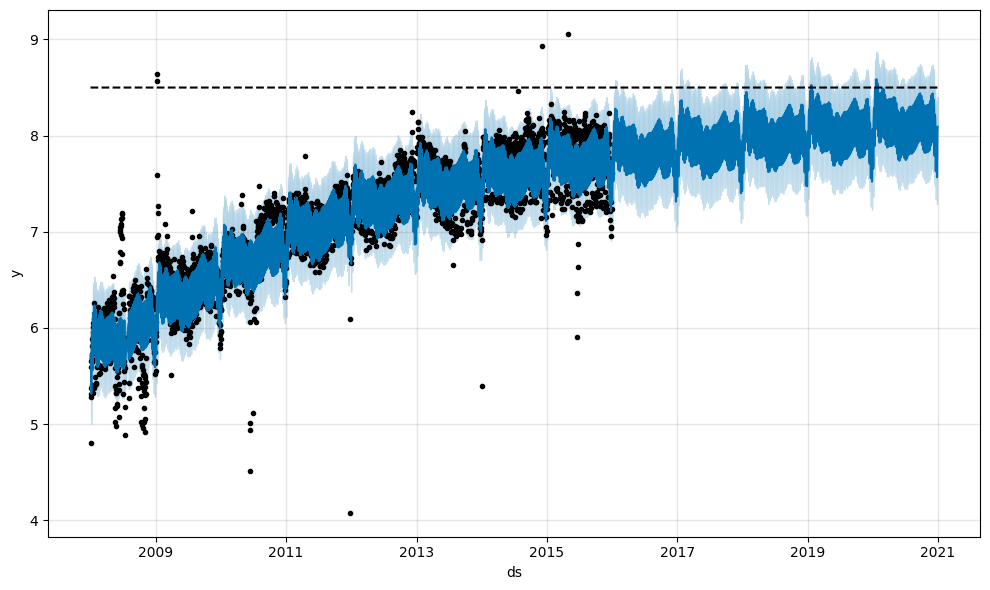

In [15]:
future = m.make_future_dataframe(periods=1826)
future['cap'] =  8.5
fcst = m.predict(future)
fig = m.plot(fcst)

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\0np9pfzn.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\qw3irq8z.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=13205', 'data', 'file=C:\\Users\\aksha\\

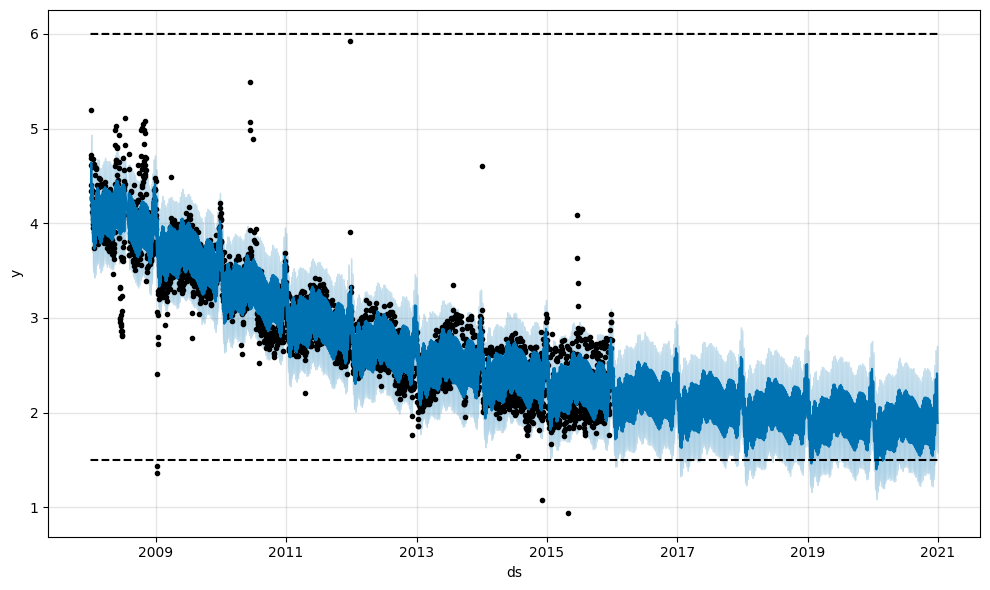

In [16]:
df['y'] = 10 - df['y']
df['cap'] = 6
df['floor'] = 1.5
future['cap'] = 6
future['floor'] = 1.5
m = Prophet(growth='logistic')
m.fit(df)
fcst = m.predict(future)
fig = m.plot(fcst)

### Trend ChangePoints

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\wkshcpg3.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\g_oc04zr.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=36992', 'data', 'file=C:\\Users\\aksha\\

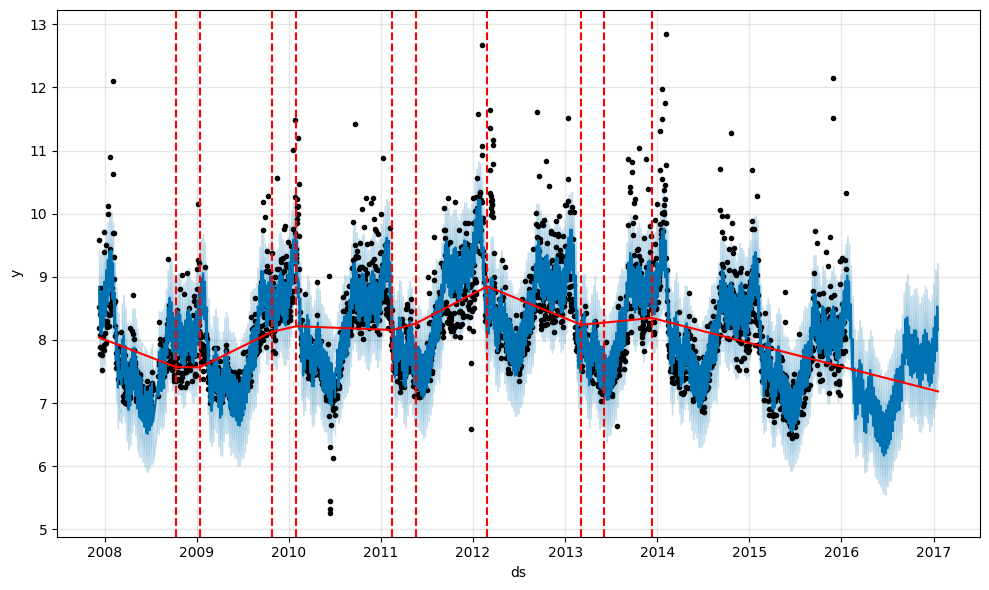

In [22]:
from prophet.plot import add_changepoints_to_plot

df = peyton_data.copy()
m = Prophet()
m.fit(df)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)

fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\3ymk5_0i.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\kuyfvm36.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=3663', 'data', 'file=C:\\Users\\aksha\\A

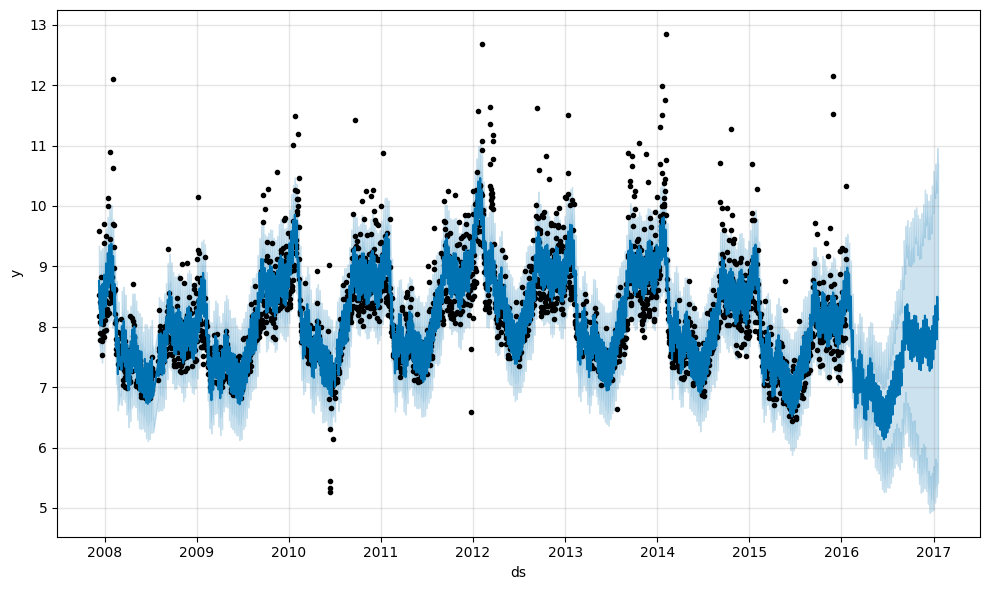

In [25]:
m = Prophet(changepoint_prior_scale=0.5)
forecast = m.fit(df).predict(future)
fig = m.plot(forecast)

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\d3n_mkhq.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\77jf3wl5.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=16042', 'data', 'file=C:\\Users\\aksha\\

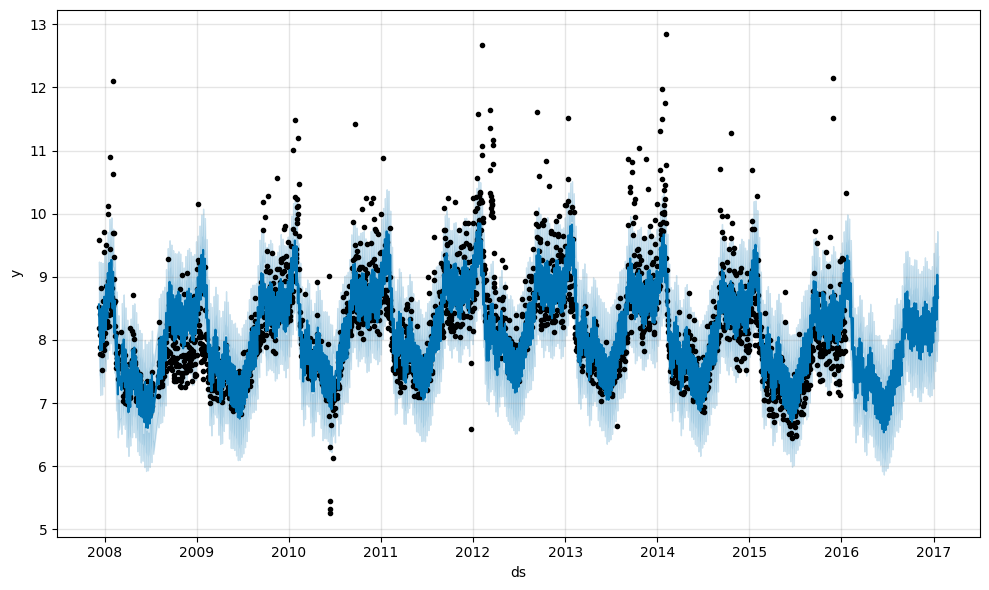

In [26]:
m = Prophet(changepoint_prior_scale=0.001)
forecast = m.fit(df).predict(future)
fig = m.plot(forecast)

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\qagf4n73.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\njn49y2y.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=47936', 'data', 'file=C:\\Users\\aksha\\

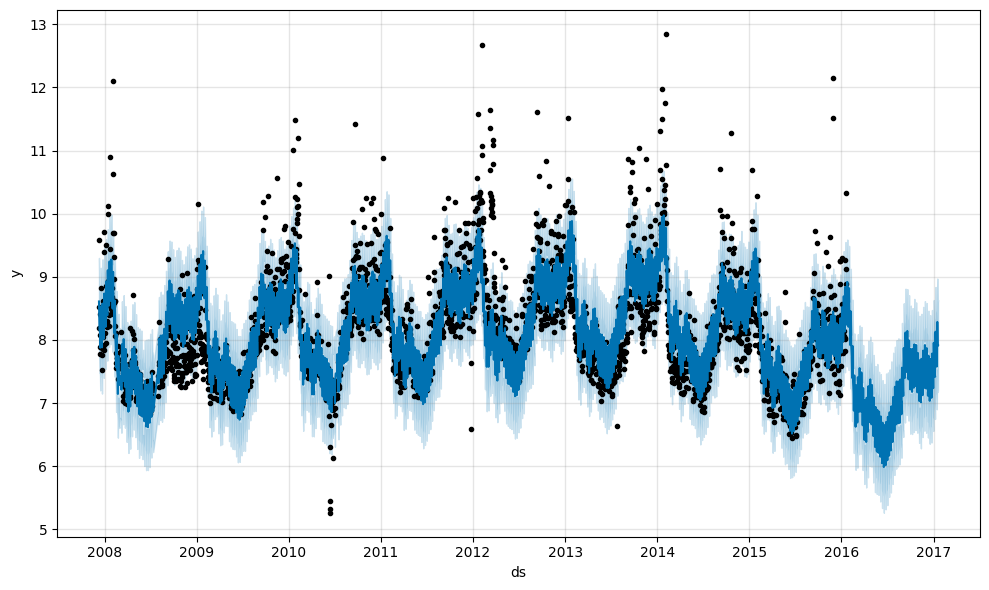

In [27]:
m = Prophet(changepoints=['2014-01-01'])
forecast = m.fit(df).predict(future)
fig = m.plot(forecast)

### Seasoality, Holiday Effects & Regressors

In [28]:
playoffs = pd.DataFrame({
    'holiday': 'playoff',
    'ds': pd.to_datetime(['2008-01-13', '2009-01-03', '2010-01-16',
                        '2010-01-24', '2010-02-07', '2011-01-08',
                        '2013-01-12', '2014-01-12', '2014-01-19',
                        '2014-02-02', '2015-01-11', '2016-01-17',
                        '2016-01-24', '2016-02-07']),
    'lower_window':0,
    'upper_window':1
})
superbowls = pd.DataFrame({
  'holiday': 'superbowl',
  'ds': pd.to_datetime(['2010-02-07', '2014-02-02', '2016-02-07']),
  'lower_window': 0,
  'upper_window': 1,
})

holidays = pd.concat((playoffs, superbowls))

In [32]:
m = Prophet(holidays=holidays)
forecast = m.fit(df).predict(future)

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\nh3teyxa.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\a3_vxzl1.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=43696', 'data', 'file=C:\\Users\\aksha\\

In [35]:
forecast[(forecast['playoff'] + forecast['superbowl']).abs() > 0][['ds', 'playoff', 'superbowl']][-10:]

,ds,playoff,superbowl
2190,2014-02-02,1.228031,1.201321
2191,2014-02-03,1.901884,1.451541
2532,2015-01-11,1.228031,0.000000
2533,2015-01-12,1.901884,0.000000
2901,2016-01-17,1.228031,0.000000
2902,2016-01-18,1.901884,0.000000
2908,2016-01-24,1.228031,0.000000
2909,2016-01-25,1.901884,0.000000
2922,2016-02-07,1.228031,1.201321
2923,2016-02-08,1.901884,1.451541


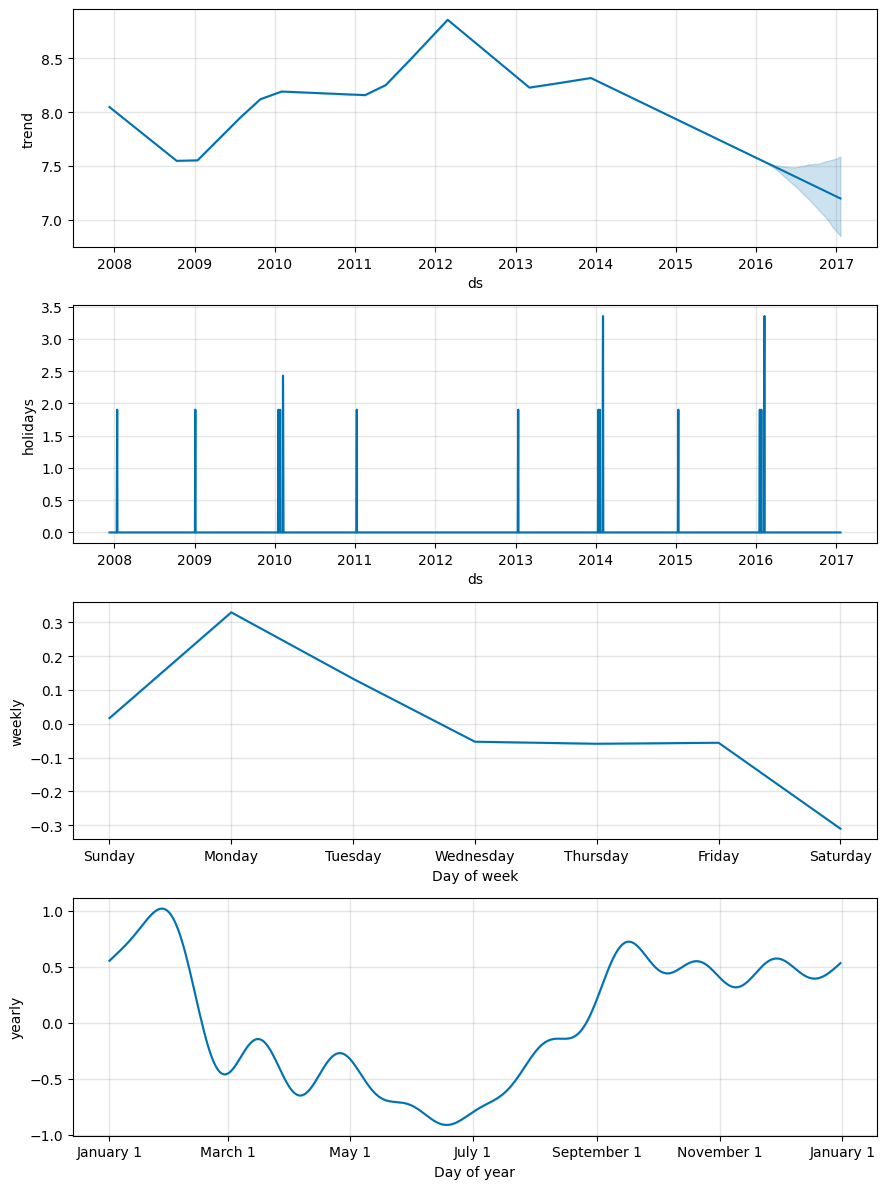

In [38]:
fig = m.plot_components(forecast)

#### Country specific holidays

In [42]:
m = Prophet(holidays=holidays)
m.add_country_holidays(country_name='India')
m.fit(df)

m.train_holiday_names

DEBUG	Task(Task-3) cmdstanpy:command.py:do_command()- cmd: where.exe tbb.dll
cwd: None
DEBUG	Task(Task-3) cmdstanpy:model.py:__init__()- TBB already found in load path
INFO	Task(Task-3) prophet:forecaster.py:parse_seasonality_args()- Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\fx4im9c8.json
DEBUG	Task(Task-3) cmdstanpy:filesystem.py:_temp_single_json()- input tempfile: C:\Users\aksha\AppData\Local\Temp\tmpkptp33vn\b_9d0h8d.json
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- idx 0
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- running CmdStan, num_threads: None
DEBUG	Task(Task-3) cmdstanpy:model.py:_run_cmdstan()- CmdStan args: ['C:\\Users\\aksha\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=23167', 'data', 'file=C:\\Users\\aksha\\

0                playoff
1              superbowl
2           Republic Day
3       Independence Day
4         Gandhi Jayanti
5         Buddha Purnima
6                 Diwali
7            Janmashtami
8               Dussehra
9        Mahavir Jayanti
10       Maha Shivaratri
11    Guru Nanak Jayanti
12                Ashura
13    Prophet's Birthday
14           Eid al-Fitr
15           Eid al-Adha
16           Good Friday
17             Christmas
dtype: object